# Análise Exploratória de Dados (EDA) - Série Histórica de Preços do Arroz

### Validação do Ambiente de Execução
Este bloco realiza uma checagem do interpretador ativo para garantir que o Jupyter Notebook está utilizando o ambiente correto e mapeando adequadamente os caminhos das bibliotecas.

In [3]:
import sys

print("Caminho do Python atual:", sys.executable)
print("\nVersão do Python:", sys.version)
print("\nLista de caminhos de busca (sys.path):")
for path in sys.path:
  print("-", path)

Caminho do Python atual: c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\python.exe

Versão do Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]

Lista de caminhos de busca (sys.path):
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\python313.zip
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\DLLs
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\Lib
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313
- 
- C:\Users\Bruno Origem Noronha\AppData\Roaming\Python\Python313\site-packages
- c:\Users\Bruno Origem Noronha\AppData\Local\Programs\Python\Python313\Lib\site-packages


### Gerenciamento Robusto de Dependências
Este bloco realiza a instalação programática das bibliotecas essenciais (`pandas`, `numpy`, `matplotlib`) de forma segura, utilizando o módulo `subprocess` em conjunto com o caminho absoluto do interpretador Python ativo (`sys.executable`).

**Justificativa Técnica:** 
Diferente do comando de terminal tradicional (`!pip`), esta abordagem via script evita falhas de interpretação de shell causadas por espaços ou caracteres especiais nos diretórios do sistema operacional (como nomes de usuário no Windows), garantindo que os pacotes sejam injetados com precisão no kernel correto do projeto.

In [4]:
import subprocess
import sys

# Instalação limpa utilizando o executável de forma segura para caminhos com espaços
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "pandas", "numpy", "matplotlib"]
)
print("Bibliotecas instaladas com sucesso!")

Bibliotecas instaladas com sucesso!


### Inicialização do Ambiente e Identidade Visual Padrão
Este bloco realiza a importação das bibliotecas fundamentais para computação científica e manipulação de dados (`pandas`, `numpy`, `matplotlib`) e define a identidade visual global para todas as figuras da monografia.

**Justificativa Técnica:** 
O uso do dicionário `plt.rcParams.update()` padroniza elementos estéticos essenciais — como a família tipográfica limpa (`sans-serif`), a espessura sutil das bordas dos eixos e a resolução de alta definição (`figure.dpi = 300`) —, garantindo consistência visual e um padrão gráfico estritamente profissional para exportação direta para o documento final.

In [5]:
# Importações fundamentais para manipulação de dados e gráficos
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuração de identidade visual padrão para a monografia
LIGHT = "#f8f9fa"
ACCENT = "#2c3e50"  # Cor principal para as séries
ACCENT_SEC = "#e67e22"  # Cor de destaque

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 0.8,
    "figure.dpi": 300,  # Garante alta resolução ao exportar as figuras
})

print("Ambiente inicializado com sucesso!")

Ambiente inicializado com sucesso!


### Carregamento e Inspeção Inicial da Base de Dados
Este bloco realiza a importação do dataset tratado de preços do arroz a partir do diretório processado do projeto e executa uma auditoria estrutural inicial dos dados.

**Justificativa Técnica:** 
O uso de `os.path.join()` assegura a portabilidade dos caminhos de diretório entre diferentes sistemas operacionais (como Windows e Linux), evitando erros de referência de arquivos. Em seguida, o método `pd.read_csv()` carrega a série histórica para a memória, enquanto `df_arroz.head()` e `df_arroz.info()` permitem inspecionar visualmente o esquema, validar os tipos primitivos das colunas e checar a integridade estrutural (como contagem de registros e ausência de nulos) antes da modelagem.

In [6]:
import os

# Caminho relativo para o dataset processado de arroz
caminho_dados = os.path.join("..", "data", "processed", "preco_arroz_limpo.csv")

# Se o arquivo estiver na mesma raiz ou se preferir o caminho direto:
# caminho_dados = "../data/processed/preco_arroz_limpo.csv"

# Carregando o DataFrame
df_arroz = pd.read_csv(caminho_dados)

# Exibindo as 5 primeiras linhas para conferir as colunas (ex: Data, Preço)
display(df_arroz.head())

# Exibindo informações gerais (tipos de dados e valores nulos)
df_arroz.info()

,data,preco_brl,preco_usd
0,2008-01-02,23.79,13.43
1,2008-01-03,24.14,13.78
2,2008-01-04,24.23,13.81
3,2008-01-05,24.23,13.81
4,2008-01-06,24.23,13.81


<class 'pandas.DataFrame'>
RangeIndex: 6684 entries, 0 to 6683
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   data       6684 non-null   str    
 1   preco_brl  6684 non-null   float64
 2   preco_usd  6684 non-null   float64
dtypes: float64(2), str(1)
memory usage: 156.8 KB


### Conversão Temporal e Visualização da Série Histórica (BRL)
Este bloco realiza o tratamento cronológico dos dados e gera a primeira visualização gráfica oficial da série histórica de preços do arroz.

**Justificativa Técnica:** 
Primeiramente, a coluna `data` é convertida para o tipo `datetime` do Pandas e o DataFrame é ordenado cronologicamente, assegurando a coerência matemática para o eixo temporal. Em seguida, utiliza-se a biblioteca `matplotlib` configurada com a identidade visual da monografia para plotar a evolução dos preços em Reais (BRL) entre 2008 e 2026. A adição de grade pontilhada, legendas customizadas e o método `plt.tight_layout()` garantem o rigor estético e a legibilidade exigidos em trabalhos acadêmicos.

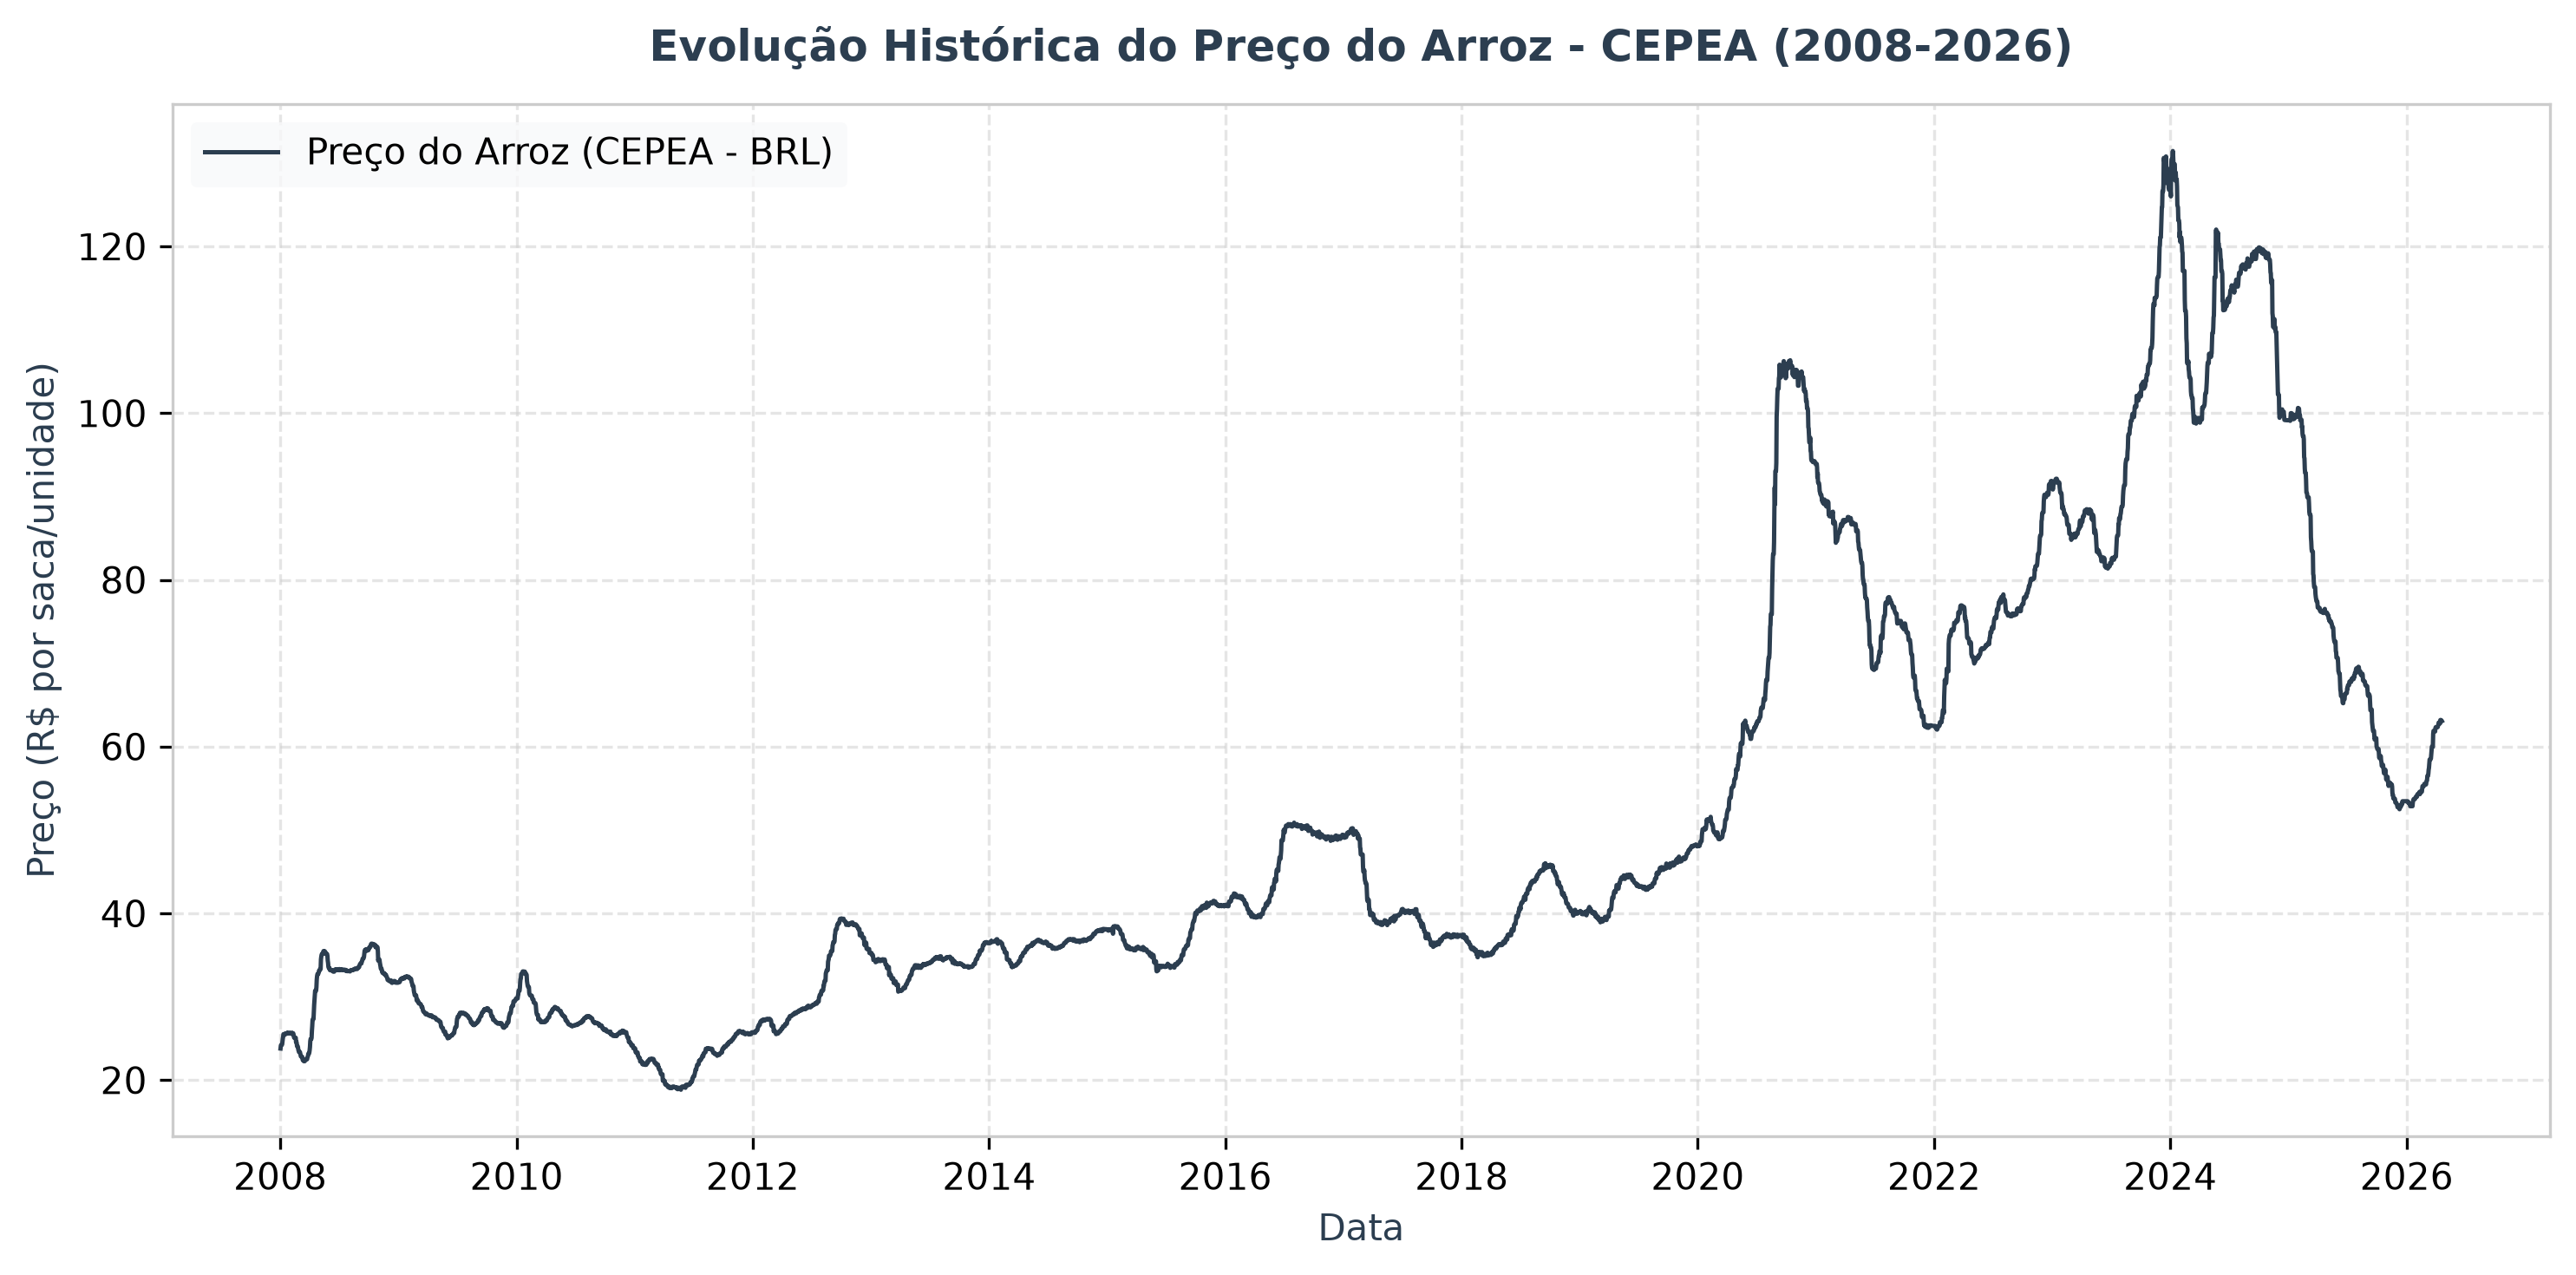

In [7]:
# 1. Convertendo a coluna 'data' para o formato datetime do Pandas
df_arroz['data'] = pd.to_datetime(df_arroz['data'])

# 2. Ordenando cronologicamente por garantia
df_arroz = df_arroz.sort_values('data').reset_index(drop=True)

# 3. Plotagem do Gráfico Histórico de Preços (BRL)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df_arroz['data'],
    df_arroz['preco_brl'],
    color=ACCENT,
    linewidth=1.2,
    label='Preço do Arroz (CEPEA - BRL)',
)

# Estilização acadêmica para a monografia
ax.set_title(
    'Evolução Histórica do Preço do Arroz - CEPEA (2008-2026)',
    fontsize=12,
    pad=12,
    color=ACCENT,
    weight='bold',
)
ax.set_xlabel('Data', fontsize=10, color=ACCENT)
ax.set_ylabel('Preço (R$ por saca/unidade)', fontsize=10, color=ACCENT)
ax.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.legend(frameon=True, facecolor=LIGHT, edgecolor='none')

# Ajusta o layout para evitar cortes
plt.tight_layout()

# Exibe o gráfico no notebook
plt.show()

A visualização da série histórica do preço do arroz (CEPEA) em Reais (BRL) entre 2008 e 2026[cite: 4] evidencia dinâmicas macroeconômicas importantes para o escopo do TCC:

* **Período de Estabilidade (2008–2019):** Os anos iniciais apresentam patamares de preços predominantemente estáveis, oscilando majoritariamente entre R$ 20,00 e R$ 40,00 por saca[cite: 4], refletindo um cenário de menor volatilidade inflacionária e cambial no setor arrozeiro.
* **Choques e Alta Volatilidade Pós-2020:** Observa-se uma inflexão acentuada a partir de 2020[cite: 4], impulsionada por fatores como a pandemia de COVID-19, desvalorização cambial, aumento nos custos dos insumos agrícolas e choques na demanda internacional. Os preços atingem picos históricos expressivos superando a marca de R$ 120,00[cite: 4].
* **Ciclicidade Recente:** Entre 2021 e 2026[cite: 4], a série demonstra oscilações cíclicas agudas, com novas pressões de alta nos anos de 2023 e 2024[cite: 4], seguidas por correções parciais no mercado físico.

**Implicação para a Modelagem:** A alta não-estacionaridade e a presença de quebras estruturais marcadas nos últimos anos reforçam a necessidade de engenharia de features robusta e o uso de modelos de séries temporais capazes de capturar tendências de longo prazo e volatilidade (como redes neurais LSTM).

### Análise de Sazonalidade Mensal dos Preços
Esta seção investiga a presença de padrões sazonais recorrentes na série histórica de preços do arroz, avaliando o comportamento entre os meses do ano para identificar possíveis ciclos de safra e entressafra.

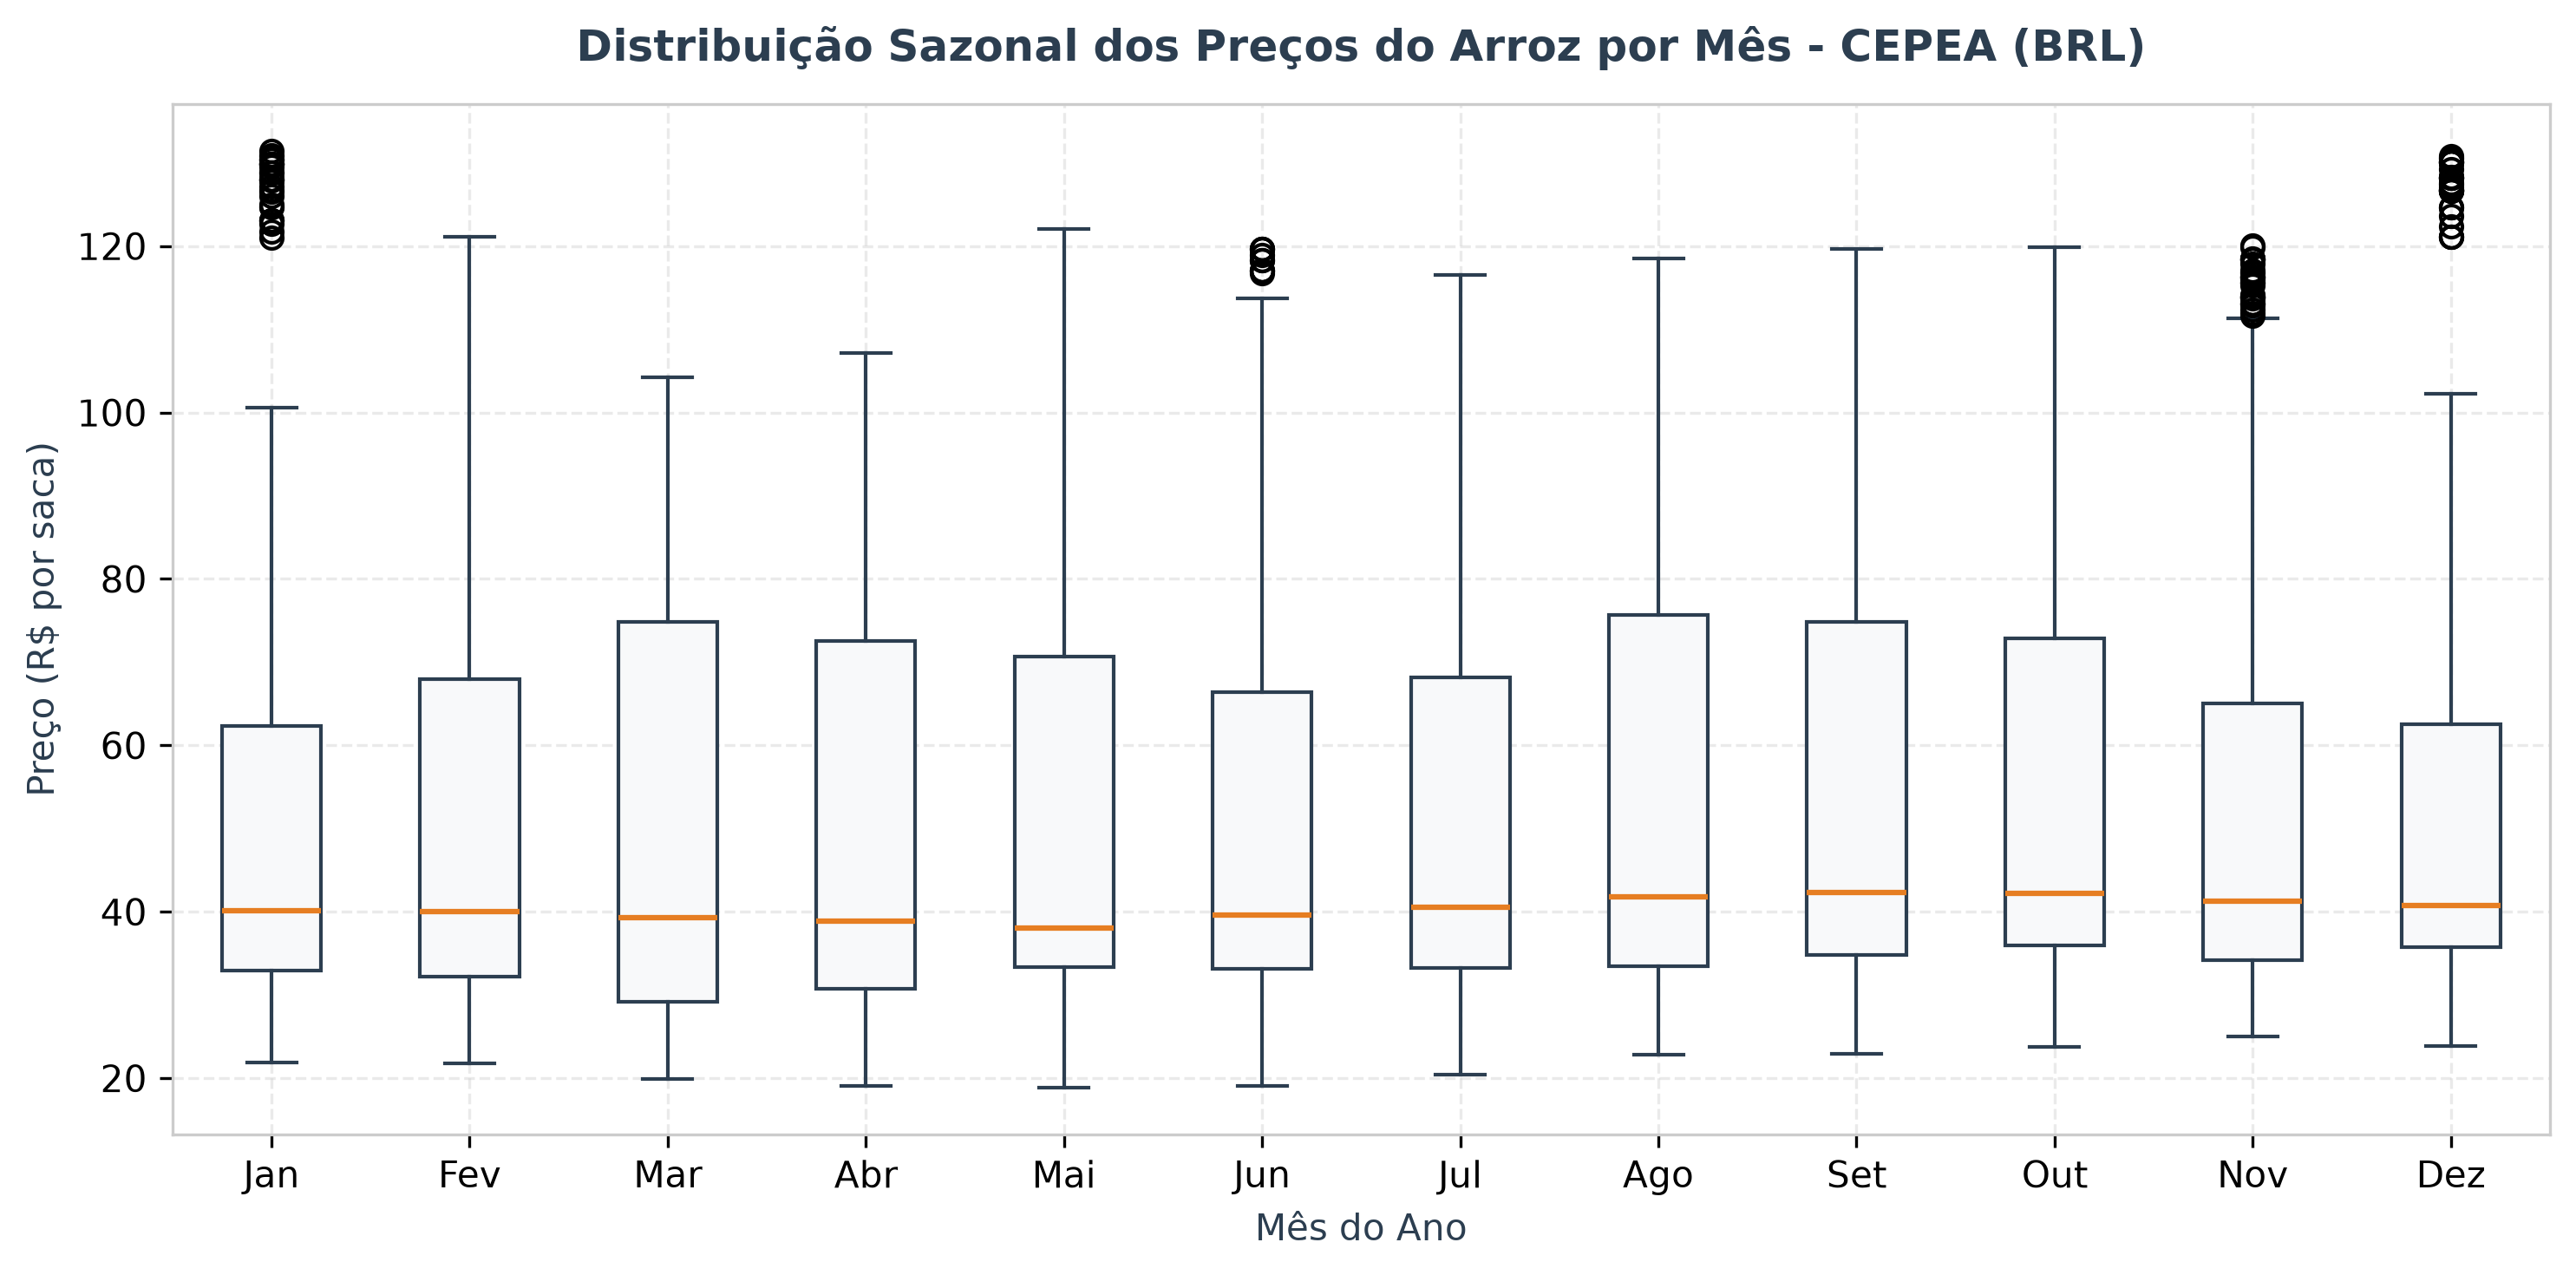

In [8]:
# 1. Extraindo o mês de cada registro para análise sazonal
df_arroz['mes'] = df_arroz['data'].dt.month

# 2. Criando o Gráfico de Sazonalidade (Boxplot)
fig, ax = plt.subplots(figsize=(10, 5))

dados_por_mes = [df_arroz[df_arroz['mes'] == m]['preco_brl'] for m in range(1, 13)]

bp = ax.boxplot(
    dados_por_mes,
    patch_artist=True,
    boxprops=dict(facecolor=LIGHT, color=ACCENT, linewidth=1),
    medianprops=dict(color=ACCENT_SEC, linewidth=1.5),
    whiskerprops=dict(color=ACCENT, linewidth=1),
    capprops=dict(color=ACCENT, linewidth=1),
)

# Estilização do gráfico
ax.set_title('Distribuição Sazonal dos Preços do Arroz por Mês - CEPEA (BRL)', fontsize=12, pad=12, color=ACCENT, weight='bold')
ax.set_xlabel('Mês do Ano', fontsize=10, color=ACCENT)
ax.set_ylabel('Preço (R$ por saca)', fontsize=10, color=ACCENT)
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc')

plt.tight_layout()
plt.show()

O gráfico de caixas (*boxplot*) acima agrupa e resume a distribuição estatística dos preços do arroz para cada mês ao longo de toda a série histórica (2008–2026). Diferente da visão linear temporal, esta abordagem permite avaliar o comportamento cíclico do mercado agrícola sob a ótica de cada período do ano:

* **Comportamento das Medianas (Linhas Laranjas):** Observa-se que as medianas dos preços mensais mantêm-se em patamares bastante homogêneos ao longo de todos os meses, oscilando de forma estável em torno de R$ 40,00 por saca. Isso indica que, na macrovisão de longo prazo, o mês isolado não determina de forma previsível uma mudança drástica no nível de preços.
* **Dispersão e Amplitude (Intervalo Interquartil):** As caixas e as hastes apresentam variações de amplitude semelhantes entre os meses, demonstrando que a volatilidade interna de preços e a faixa onde se concentram 50% dos dados centrais comportam-se de maneira parecida ao longo de todo o ano.
* **Ocorrência de *Outliers* (Valores Atípicos):** Os pontos isolados no topo do gráfico (evidenciados em meses como janeiro, novembro e dezembro) representam os anos de choques de preços extraordinários. O fato de esses *outliers* estarem distribuídos em diferentes épocas reforça que picos históricos expressivos (superiores a R$ 120,00) não são subprodutos de uma sazonalidade fixa de safra/entressafra, mas sim reflexo de eventos macroeconômicos e estruturais externos.

**Implicação para o TCC:** A ausência de uma sazonalidade mensal rígida e dominante sugere que os modelos preditivos devem priorizar variáveis macroeconômicas (como taxa de câmbio, inflação e choques de oferta globais) em detrimento de suposições puramente sazonais para capturar as flutuações extremas da commodity.

### Análise de Volatilidade e Retornos Percentuais
Para avaliar o grau de risco e a estabilidade da commodity ao longo da série histórica, calcula-se a variação percentual período a período (`pct_change()`). Esta métrica é fundamental para evidenciar os momentos de maior instabilidade e choques de mercado.

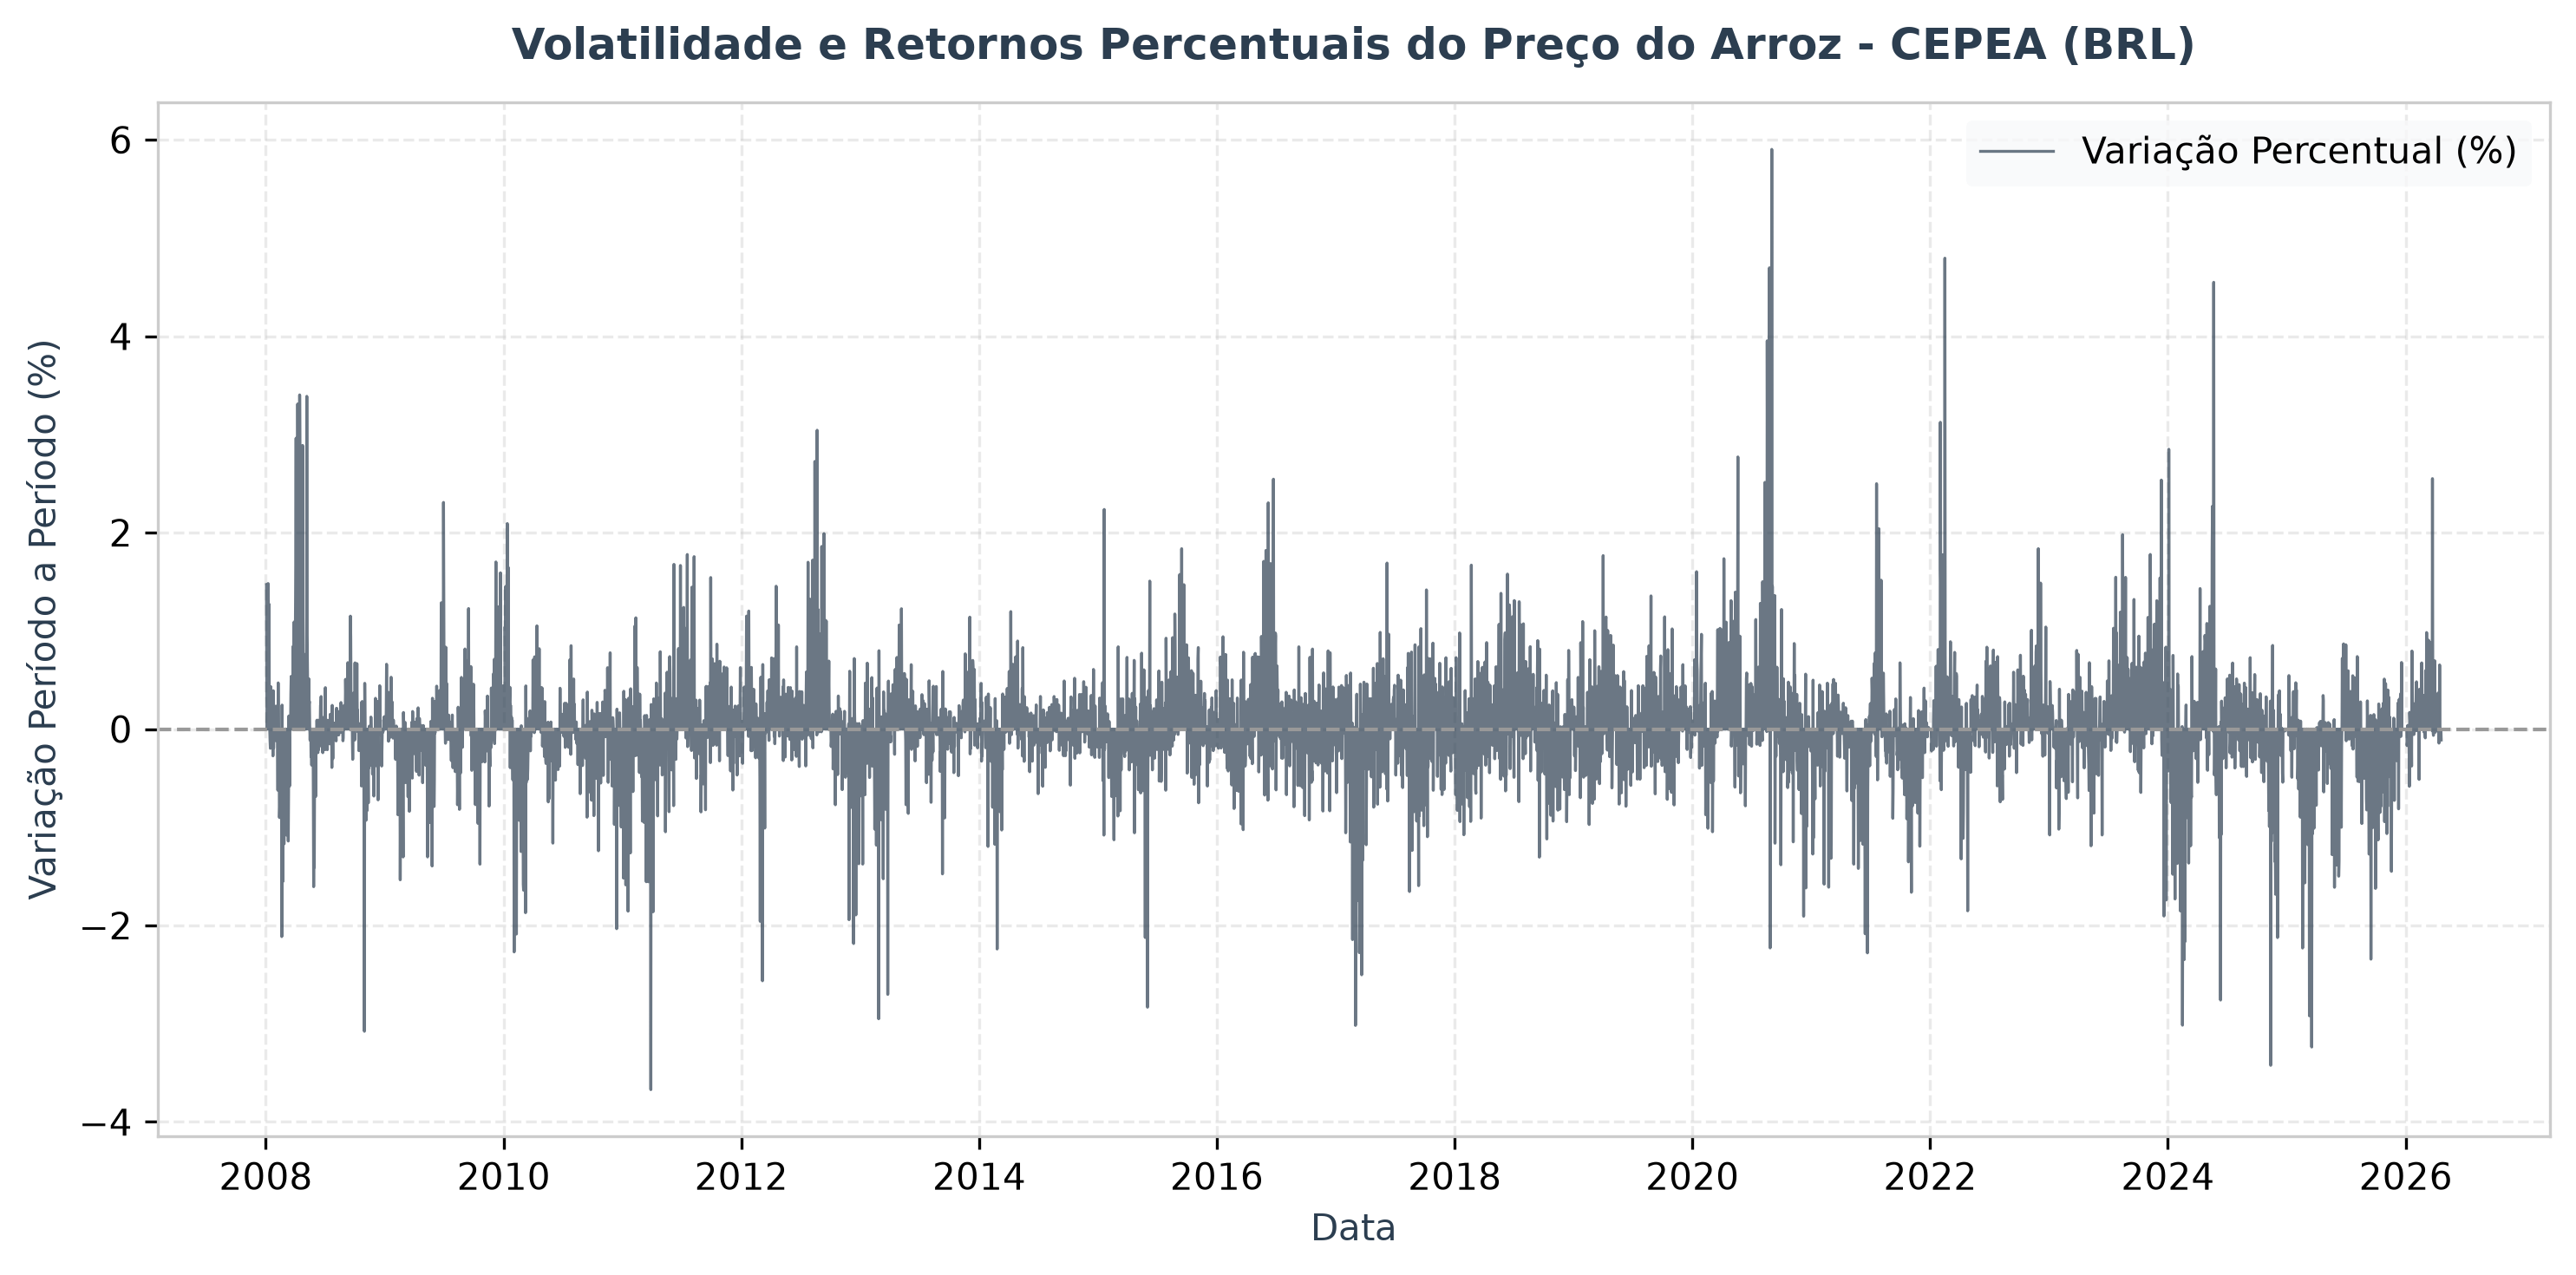

In [11]:
# 1. Calculando a variação percentual (retornos) entre os períodos
df_arroz['retorno_pct'] = df_arroz['preco_brl'].pct_change() * 100

# 2. Criando o gráfico de volatilidade dos retornos
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_arroz['data'], df_arroz['retorno_pct'], color=ACCENT, linewidth=0.8, alpha=0.7, label='Variação Percentual (%)')

ax.set_title('Volatilidade e Retornos Percentuais do Preço do Arroz - CEPEA (BRL)', fontsize=12, pad=12, color=ACCENT, weight='bold')
ax.set_xlabel('Data', fontsize=10, color=ACCENT)
ax.set_ylabel('Variação Período a Período (%)', fontsize=10, color=ACCENT)
ax.axhline(0, color='#999999', linestyle='--', linewidth=1) # Linha de referência no zero
ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.legend(frameon=True, facecolor=LIGHT, edgecolor='none')

plt.tight_layout()
plt.show()

O gráfico de variações percentuais período a período (`pct_change`) exibe a intensidade das flutuações e a instabilidade dos preços do arroz ao longo de toda a série histórica (2008–2026)[cite: 2]. A linha tracejada em **0%** atua como uma referência de estabilidade absoluta, onde valores acima indicam alta de preços em relação ao período anterior e valores abaixo indicam queda[cite: 2].

* **Intensidade das Oscilações:** Observa-se que a amplitude das variações não é uniforme ao longo do tempo[cite: 2]. Enquanto alguns períodos apresentam oscilações mais contidas e próximas ao eixo central, outros momentos exibem desvios abruptos.
* **Picos de Volatilidade:** Os momentos de maior dispersão e instabilidade concentram-se em janelas macroeconômicas específicas — com destaque para os choques registrados por volta de 2008, em 2020 e no intervalo mais recente (2024–2026)[cite: 2], onde os retornos percentuais esticam-se consideravelmente para cima e para baixo.
* **Comportamento da Série:** A visualização comprova que a volatilidade condicional do mercado de arroz se intensifica em momentos de crise, evidenciando a forte presença de rupturas e a não-estacionariedade da série temporal[cite: 2].

**Implicação para o TCC:** Esta análise justifica empiricamente a necessidade de empregar modelos preditivos avançados (como redes neurais LSTM) capazes de capturar e aprender com choques de variância e dinâmicas complexas de mercado, superando as limitações de abordagens puramente lineares ou estáticas.

### Perfil Sazonal Médio e Banda de Variação Mensal
Para isolar e examinar o comportamento cíclico médio ao longo de um ano típico, calcula-se a média aritmética (ou mediana) dos preços para cada mês agrupando toda a série histórica (2008–2026), acompanhada de uma faixa de desvio padrão. Essa métrica permite identificar com precisão estatística os períodos de pressão de alta (entressafra) e baixa (colheita/safra).

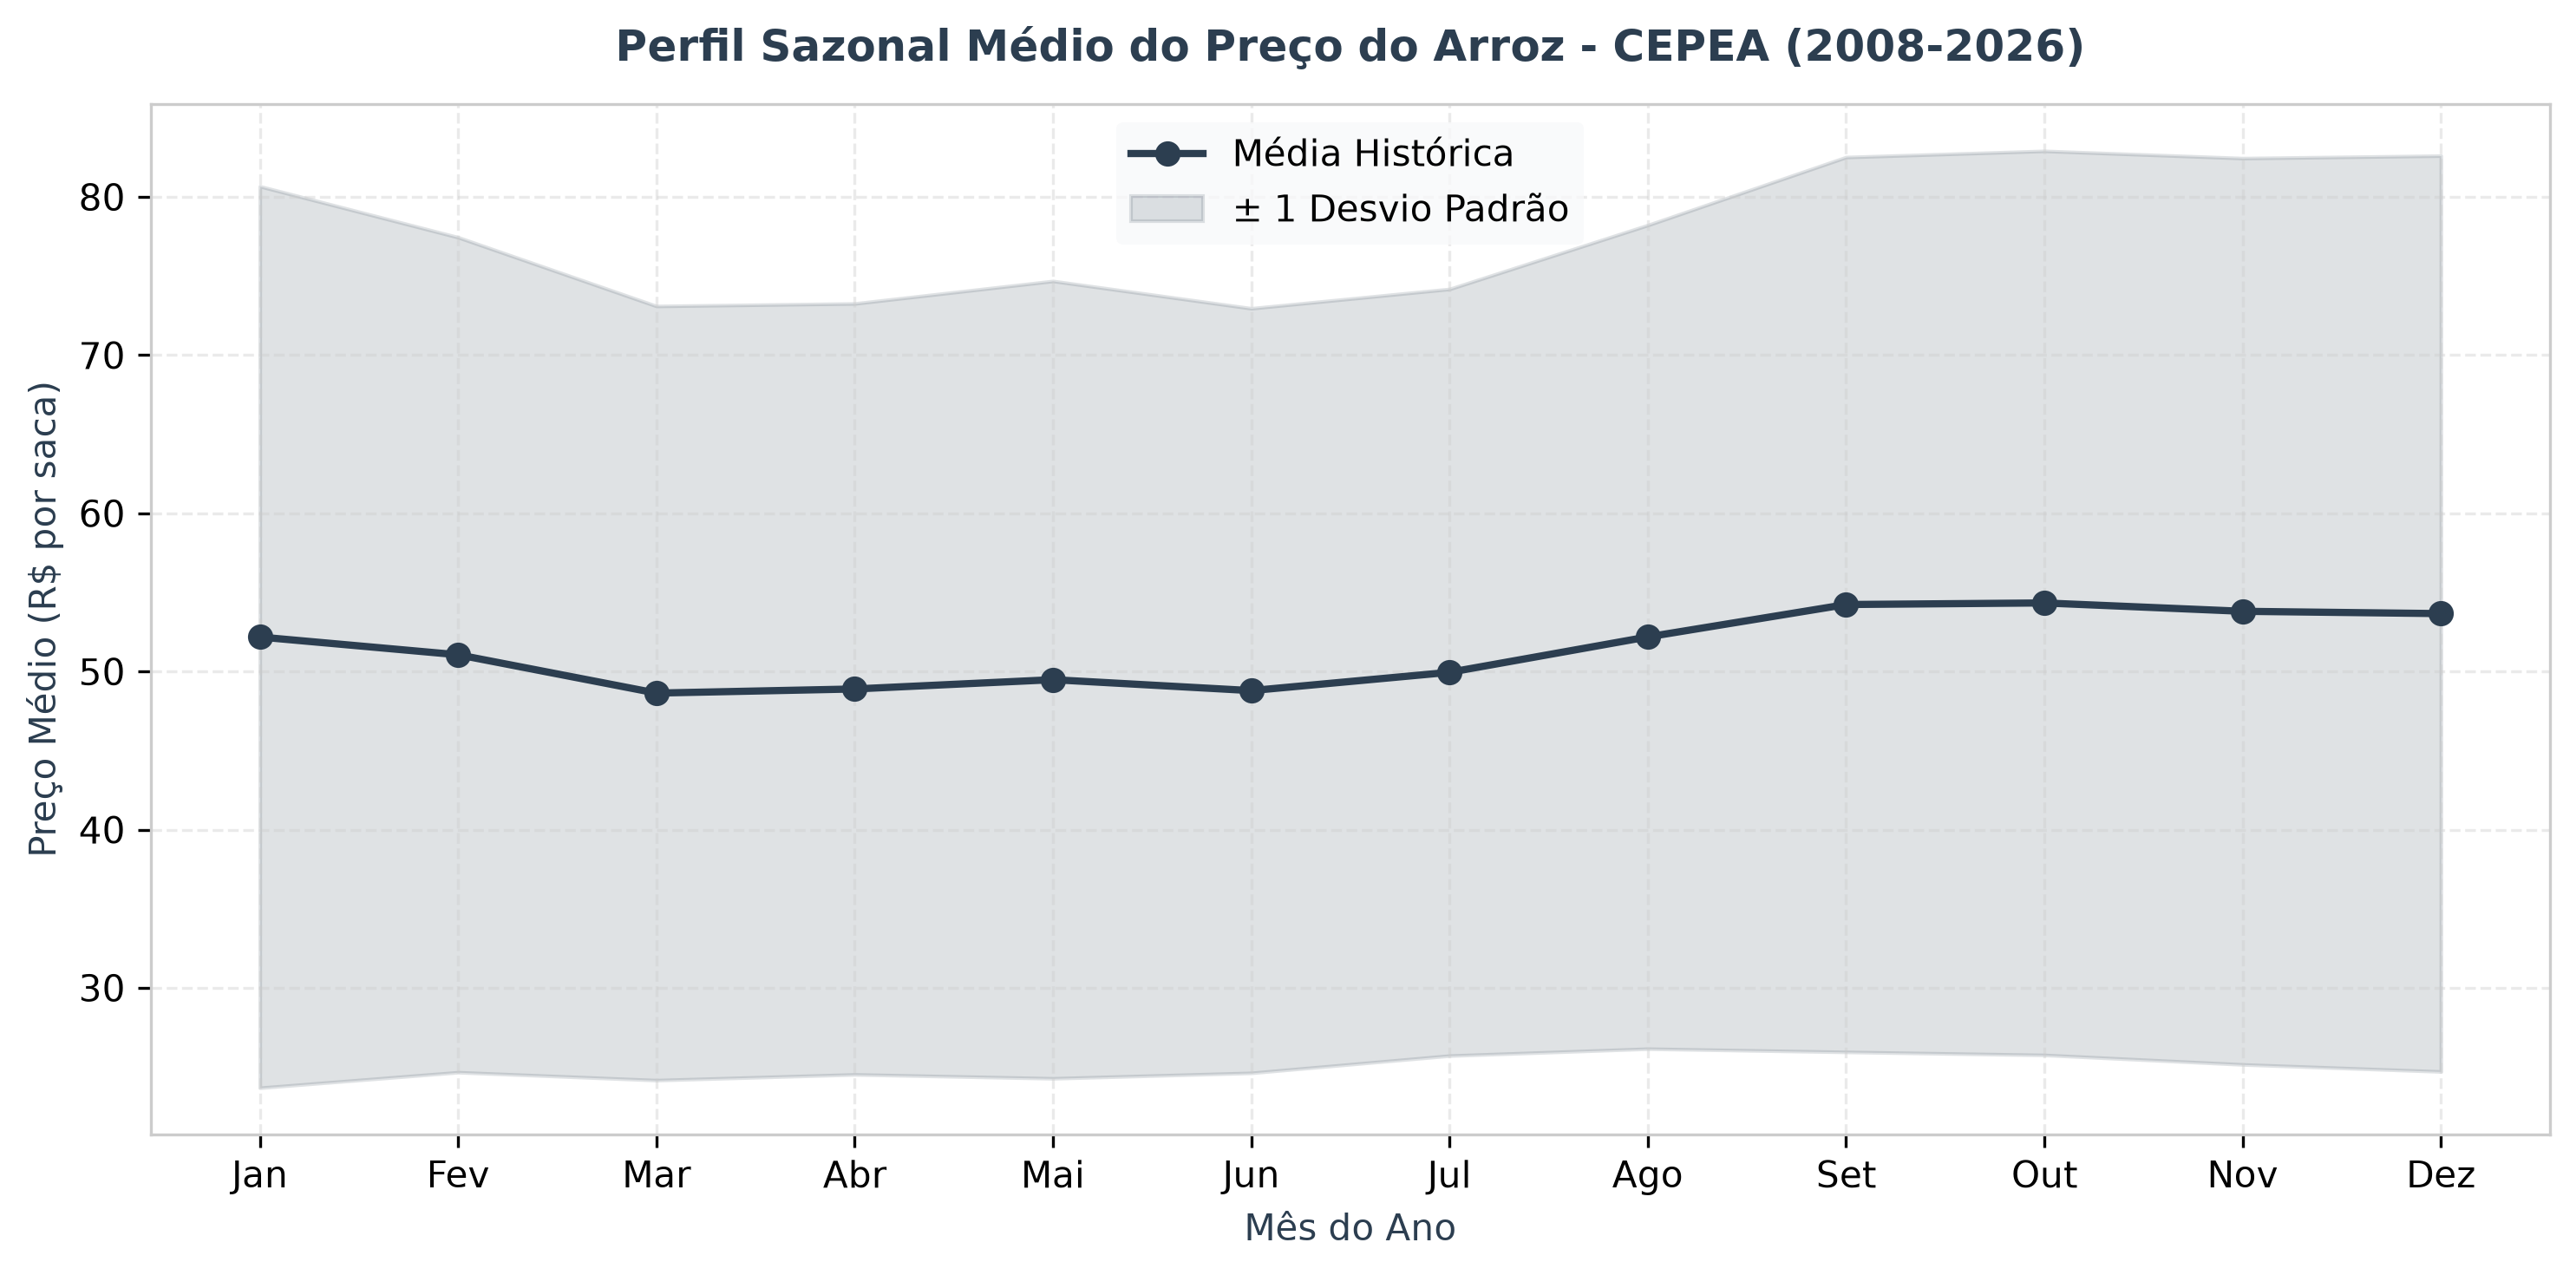

In [13]:
# 1. Garantindo que a coluna de data seja datetime e extraindo o mês
df_arroz['data'] = pd.to_datetime(df_arroz['data'])
df_arroz['mes'] = df_arroz['data'].dt.month

# 2. Calculando a média e o desvio padrão por mês ao longo de todos os anos
sazonalidade_stats = df_arroz.groupby('mes')['preco_brl'].agg(['mean', 'std']).reset_index()

# Mapeando os nomes dos meses em português para o eixo X
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# 3. Criando o gráfico de linha com banda de desvio padrão
fig, ax = plt.subplots(figsize=(10, 5))

# Linha principal da média histórica
ax.plot(sazonalidade_stats['mes'], sazonalidade_stats['mean'], color=ACCENT, linewidth=2.0, marker='o', label='Média Histórica')

# Banda de variação (Desvio Padrão) para indicar a dispersão em cada mês
ax.fill_between(
    sazonalidade_stats['mes'], 
    sazonalidade_stats['mean'] - sazonalidade_stats['std'], 
    sazonalidade_stats['mean'] + sazonalidade_stats['std'], 
    color=ACCENT, alpha=0.15, label='± 1 Desvio Padrão'
)

ax.set_title('Perfil Sazonal Médio do Preço do Arroz - CEPEA (2008-2026)', fontsize=12, pad=12, color=ACCENT, weight='bold')
ax.set_xlabel('Mês do Ano', fontsize=10, color=ACCENT)
ax.set_ylabel('Preço Médio (R$ por saca)', fontsize=10, color=ACCENT)
ax.set_xticks(sazonalidade_stats['mes'])
ax.set_xticklabels(meses_nomes)
ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.legend(frameon=True, facecolor=LIGHT, edgecolor='none')

plt.tight_layout()
plt.show()

O gráfico do perfil sazonal médio sintetiza o comportamento dos preços do arroz ao longo de um ano civil padrão, agrupando toda a série histórica (2008–2026)[cite: 3]. A curva principal exibe a média aritmética mensal, enquanto a área sombreada representa a dispersão delimitada por $\pm 1$ desvio padrão[cite: 3].

* **Comportamento da Média Mensal:** A curva central demonstra que o preço médio mensal apresenta uma oscilação suave, mantendo-se predominantemente entre os patamares de R$ 48,00 e R$ 54,00 por saca[cite: 3].
* **Dispersão e Banda de Desvio Padrão:** Observa-se uma faixa de variação ampla (com limites inferiores próximos a R$ 25,00 e superiores ultrapassando os R$ 80,00)[cite: 3]. Esta amplitude elevada reflete a forte mudança de patamar macroeconômico ocorrida na série ao longo dos anos, e não um desvio sazonal estrito.
* **Consolidação da Análise:** Os dados corroboram que o mercado não possui um ciclo mensal rígido e determinístico, sendo fortemente influenciado por tendências de longo prazo e choques externos de variância.

**Implicação para o TCC:** Esta visualização fecha a Análise Exploratória de Dados (EDA) ao demonstrar estatisticamente que os ciclos anuais isolados dividem espaço com mudanças estruturais macroeconômicas, justificando de vez o uso de arquiteturas preditivas avançadas.

### Análise de Subséries Sazonais

O gráfico de subséries sazonais desagrega a série temporal em doze painéis mensais, permitindo examinar simultaneamente a evolução interanual de cada mês e o seu patamar médio de referência (destacado pela linha horizontal). 


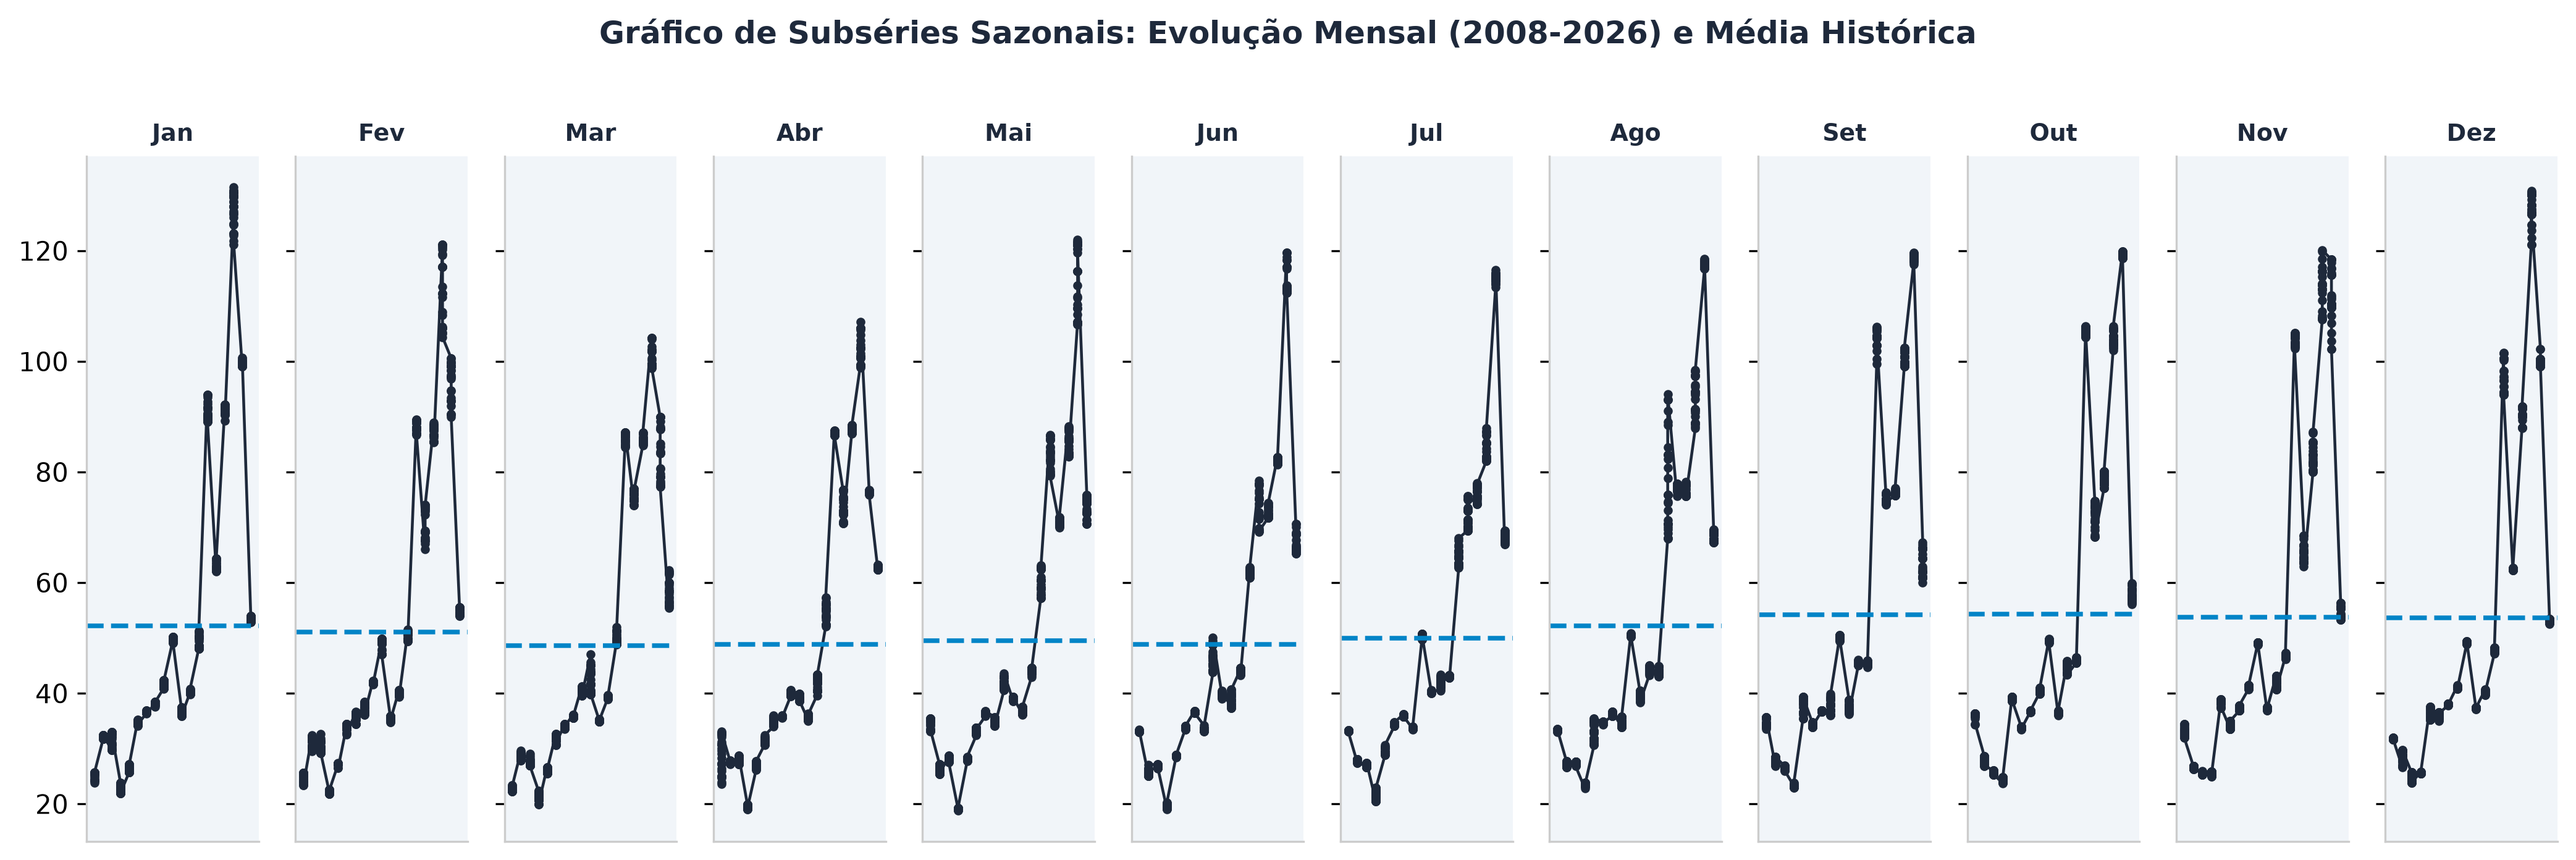

In [15]:
import matplotlib.pyplot as plt

# Definindo a paleta de cores caso não estejam declaradas no escopo global
NAVY = '#1e293b'
ACCENT = '#0284c7'
LIGHT = '#f1f5f9'

# 1. Garantindo que a coluna de data é datetime e extraindo ano e mês
df_arroz['data'] = pd.to_datetime(df_arroz['data'])
df_arroz['ano'] = df_arroz['data'].dt.year
df_arroz['mes'] = df_arroz['data'].dt.month

# 2. Calculando a média de cada mês na série histórica inteira
medias_mensais = df_arroz.groupby("mes")["preco_brl"].mean()
nomes_meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

# 3. Criando a figura com 12 painéis (um para cada mês) compartilhando o eixo Y
fig, axes = plt.subplots(1, 12, figsize=(14, 4.5), sharey=True)

for m in range(1, 13):
    ax = axes[m - 1]
    ax.set_facecolor(LIGHT)
    
    # Filtrando os dados específicos daquele mês ao longo dos anos
    dados_mes = df_arroz[df_arroz["mes"] == m]
    
    # Plotando a evolução do mês ao longo dos anos
    ax.plot(dados_mes["ano"], dados_mes["preco_brl"], marker='o', markersize=2.5, linewidth=1.1, color=NAVY)
    
    # Linha horizontal indicando a média histórica daquele mês específico
    ax.axhline(medias_mensais[m], color=ACCENT, linewidth=1.8, linestyle='--')
    
    ax.set_title(nomes_meses[m - 1], fontsize=9, color=NAVY, weight='bold')
    ax.set_xticks([]) # Remove os ticks do eixo X
    
    # Removendo bordas desnecessárias
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Gráfico de Subséries Sazonais: Evolução Mensal (2008-2026) e Média Histórica", fontsize=12, color=NAVY, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

O gráfico de subséries sazonais desagrega a série temporal em doze painéis mensais, permitindo examinar simultaneamente a evolução interanual de cada mês e o seu patamar médio de referência, representado pela linha horizontal tracejada[cite: 3].

* **Comportamento Intra-mês:** Cada painel exibe a trajetória de um mês específico entre 2008 e 2026[cite: 3]. Nota-se que a tendência macro de alta — evidenciada de forma marcante a partir de 2020 e nos anos seguintes — reflete-se de maneira uniforme em praticamente todos os meses do ano[cite: 3].
* **Estabilidade das Médias:** As linhas de referência indicam que os valores médios mensais apresentam pouca discrepância estrutural entre si, fixando-se de forma homogénea na faixa entre R$ 50,00 e R$ 54,00[cite: 3].
* **Consolidação do Padrão Temporal:** A visualização comprova que o mercado de arroz não é regido por uma sazonalidade estrita ou rigidez cíclica mensal isolada, mas sim por dinâmicas macroeconómicas globais contínuas e choques de variância[cite: 3].

**Implicação para o TCC:** A decomposição por subséries valida a robustez do conjunto de dados e ratifica que a modelagem preditiva via LSTM deve concentrar-se na captura de tendências globais e volatilidade, visto que os ciclos mensais isolados possuem baixa previsibilidade estática.

### Análise de Defasagem (Lag Plot)

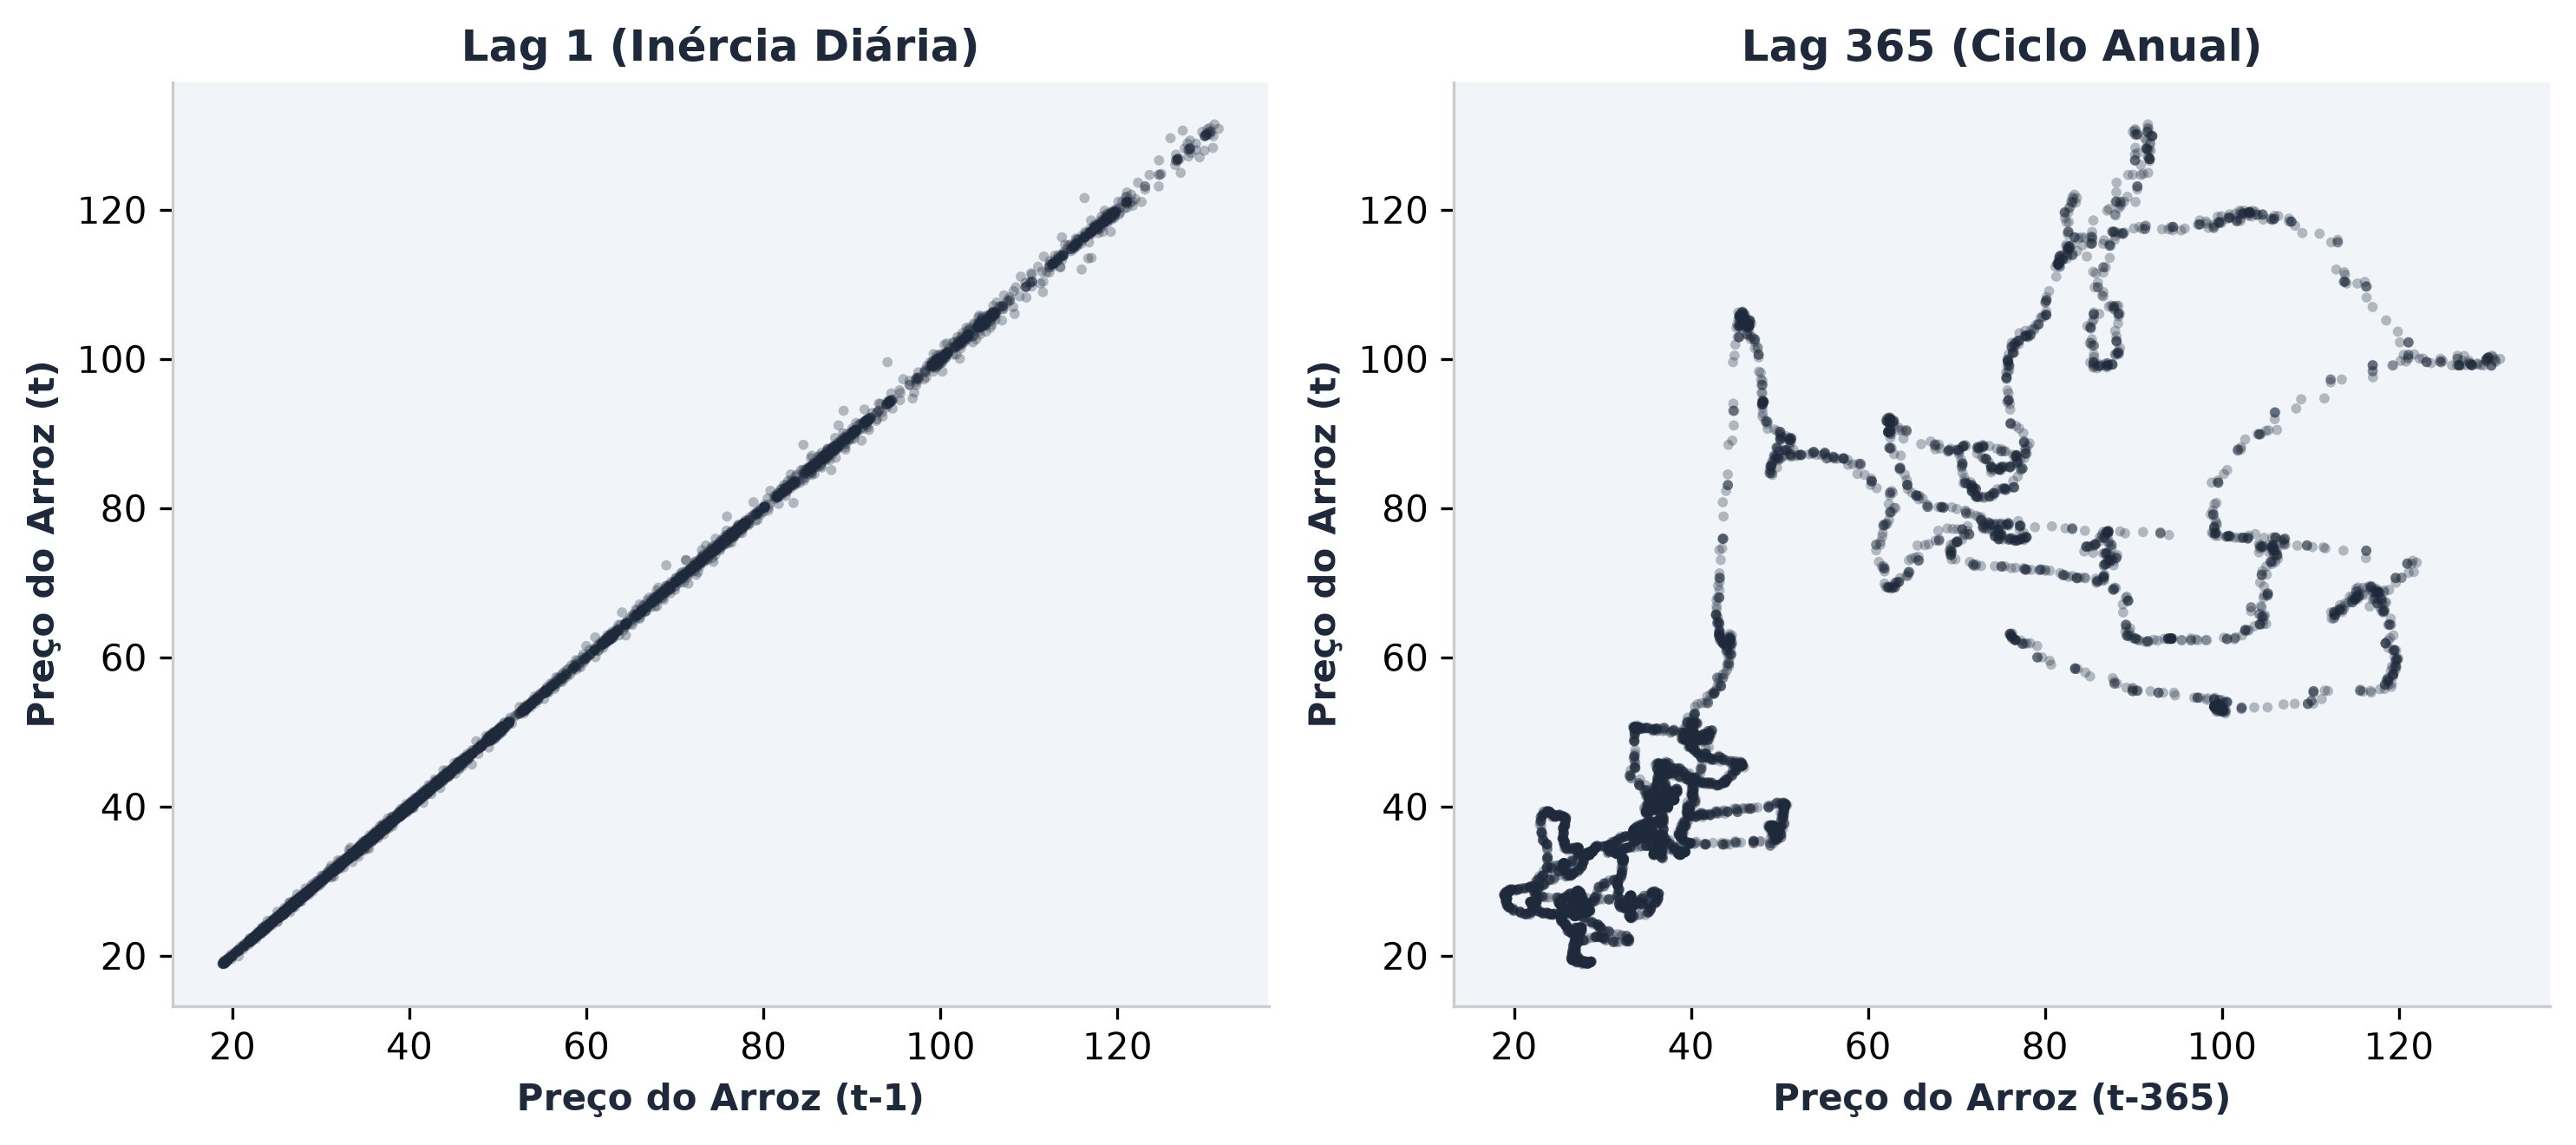

In [20]:
import matplotlib.pyplot as plt

NAVY = '#1e293b'
ACCENT = '#0284c7'
LIGHT = '#f1f5f9'

serie = df_arroz['preco_brl']

lags = [1, 365]
titulos = ["Lag 1 (Inércia Diária)", "Lag 365 (Ciclo Anual)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, lag, titulo in zip(axes, lags, titulos):
    ax.set_facecolor(LIGHT)
    
    # Reduzimos o tamanho (s=8) e aumentamos a transparência (alpha=0.3)
    # para evitar o efeito de "bloco pesado" de bolinhas
    ax.scatter(serie.shift(lag), serie, s=8, alpha=0.3, color=NAVY, edgecolor='none')
    
    ax.set_xlabel(f"Preço do Arroz (t-{lag})", fontsize=10, color=NAVY, weight='bold')
    ax.set_ylabel("Preço do Arroz (t)", fontsize=10, color=NAVY, weight='bold')
    ax.set_title(titulo, fontsize=12, color=NAVY, weight='bold')
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Para diagnosticar a estrutura de dependência temporal da série de preços do arroz com frequência diária, gerou-se o diagrama de dispersão comparando dois horizontes de defasagem distintos:

* **Lag 1 (Inércia Diária):** O painel esquerdo exibe uma concentração linear estrita ao longo da diagonal principal. Este comportamento aponta para uma altíssima autocorrelação e inércia de curto prazo, indicando que a cotação do arroz num determinado dia ($t$) é fortemente ditada pelo valor registado no dia imediatamente anterior ($t-1$).
* **Lag 365 (Ciclo Anual em Dias Corridos):** O painel direito correlaciona o preço atual com o valor exato registado um ano antes ($t-365$). A formação de estruturas em loop, agrupamentos (*clusters*) e trajetórias de transição reflete a evolução não-linear e as mudanças de patamar estrutural dos preços ao longo da série histórica (2008–2026). A dispersão e o afastamento de uma diagonal linear limpa demonstram que a sazonalidade anual não se repete de forma estritamente rígida, sofrendo forte influência de choques macroeconómicos, inflação e alterações estruturais de mercado.

**Implicações para a Modelagem LSTM:**
A evidência simultânea de uma forte dependência de curto prazo (Lag 1) e de uma dinâmica complexa e de longo alcance (Lag 365) valida a inadequação de modelos puramente lineares e justifica plenamente o emprego de redes neuronais do tipo **LSTM**, dada a sua capacidade superior de reter memória e aprender padrões sequenciais não-lineares em múltiplas escalas temporais.